# Fermi fitting development/testing

In [1]:
%reset -f
%run pylib/tools dark
from pylib.tools import np, plt, pd
from pathlib import Path
from importlib import reload
from astropy.coordinates import SkyCoord
from utilities.ipynb_docgen import show, show_date
from pylib import pixel_table as pixel_table_mod; reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel
from like3 import main as main_mod; reload(main_mod)
FermiFit = main_mod.FermiFit
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-04-08 17:03</h5>

In [2]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog('uw1617',
    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)
selected_name = roi_sources.source_names[0]
show(
    f'''Loaded {len(roi_sources)} catalog sources within {cone_size} deg of {roi_center.to_string("decimal", precision=3)}.
First selected source: {selected_name}''')
ff = PixelTable('files/kerr/toby_v4.fits', source_model=roi_sources)

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


Loaded 1 catalog sources within 1.0 deg of 98.476 17.770.
First selected source: PSRJ0633+1746

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'


{'hess': array([[5152646.07382451, 1847399.50612034],
        [1847399.50612034, 1851652.97580365]]),
 'cov': array([[ 3.02161336e-07, -3.01467235e-07],
        [-3.01467235e-07,  8.40832727e-07]]),
 'sigs': array([0.0005, 0.0009]),
 'corr': array([[ 1. , -0.6],
        [-0.6,  1. ]]),
 'grad': array([18.15603498, -6.34140108]),
 'x_fit': array([-10.29886455,   0.75923116]),
 'x_init': array([-9.5324597 ,  2.04286003]),
 'delta_loglike': 44197958.97,
 'ts_values': array([5506657.4,       nan])}

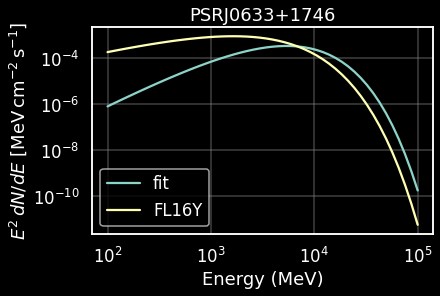

In [3]:
reload(main_mod)
FermiFit = main_mod.FermiFit
ff = FermiFit(ff)
src = roi_sources[0]
fig, ax = plt.subplots(figsize=(6,4))
with ff.preserve_parameters():
    ff.fit()
    ff.source_model.sed_plot(ax=ax, label='fit')
    new_flux_func = src.model.copy()
    
ff.source_model.sed_plot(ax=ax, label='FL16Y');
show(ff.fit_info)

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7d3e951efc70>
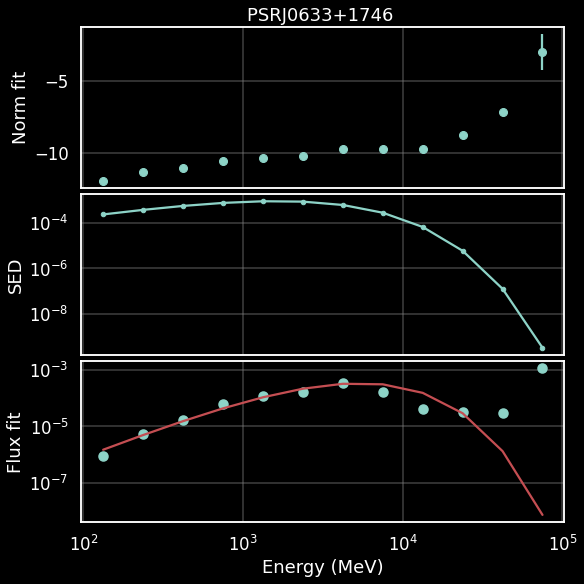

In [5]:
import pandas as pd

# --- Norm prof: fit only the normalization for each energy bin ---
# Group all bands by energy index (second element of band key); each group
# contains up to 4 PSF-type bands that share the same energy boundaries.

pt = ff.pixel_table

energy_indices = sorted({k[1] for k in pt.keys()})
src = ff.source_model[0] # the source we just fit above; should be the same as roi_sources[0]
flux_func = src.model.copy()
rows = []
with ff.preserve_parameters():
    for e_idx in energy_indices:
        keys = [k for k in pt.keys() if k[1] == e_idx]
        pt.select(keys=keys)
        ff.fit([0])
        band0 = pt[keys[0]]
        e_mev = np.sqrt(band0.e0 * band0.e1).round()
        x_fit  = ff.fit_info['x_fit'][0].round(3)
        sig    = ff.fit_info['sigs'][0].round(3)
        ts_val = ff.fit_info['ts_values'][0]
        rows.append(dict(e_idx=e_idx, e_mev=e_mev, x_fit=x_fit, sig=sig, 
                         ts=ts_val, sed=flux_func(e_mev)*e_mev**2))

pt.select()   # reset to all bands

prof = pd.DataFrame(rows)
fig, axx = plt.subplots(3,1, figsize=(8,8), sharex=True)
ax,ax2,ax3 = axx
ax.errorbar(prof['e_mev'], prof['x_fit'], yerr=prof['sig'], fmt='o', markersize=8)
ax.set_xscale('log')
# ax2.set_xlabel('Energy (MeV)')
ax.set_ylabel('Norm fit')
ax.set_title(f'{selected_name} ')
e_mev = prof['e_mev']
ax2.plot(prof['e_mev'], prof['sed'], '.-', )#label='FL16Y SED')
# ax2.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), '+', label='Norm fit SED')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylabel('SED')#r'$E^2\,dN/dE\ [\mathrm{MeV\,cm^{-2}\,s^{-1}}]$')
# ax2.legend()
ax3.scatter(prof.e_mev, 10**prof.x_fit * prof.sed/flux_func['Norm'], )# label='flux fit')
ax3.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), 'r', label='Norm fit SED')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_ylabel('Flux fit')
ax3.set_xlabel('Energy (MeV)')
# ax3.legend()
show(fig)

In [ ]:
ff.pixel_table